# I giocatori NBA tirano peggio nei momenti decisivi?

## Domanda di ricerca

**I giocatori NBA tirano peggio da 3 punti nei momenti decisivi (4° quarto e ultimi 2 minuti)?**

Il mito del *clutch gene* racconta di giocatori capaci di alzare il proprio rendimento nei momenti che contano. Dall'altra parte c'è l'ipotesi opposta: la pressione, la stanchezza e una difesa più intensa portano i giocatori a *tirare peggio* proprio quando conta di più.

In questo notebook affrontiamo la domanda come una vera indagine statistica:

1. Guardiamo i dati e facciamo un'esplorazione iniziale.
2. Modelliamo il tiro come variabile aleatoria (Bernoulli/Binomiale).
3. Confrontiamo in modo descrittivo la % da 3 nei primi tre quarti vs. il 4° quarto e il *clutch time*.
4. Verifichiamo con la **Legge dei Grandi Numeri** che la nostra stima di *p* sia affidabile.
5. Usiamo il **Teorema del Limite Centrale** per giustificare l'uso di strumenti basati sulla normale.
6. Costruiamo **intervalli di confidenza** per quantificare l'incertezza.
7. Eseguiamo un **test di ipotesi** per rispondere alla domanda iniziale.
8. Tiriamo le conclusioni.

## 1. Caricamento ed esplorazione dei dati

Iniziamo caricando il dataset e facendoci un'idea delle sue dimensioni. Filtriamo subito i tiri da 3 punti, che sono l'oggetto della nostra analisi.

In [30]:
# Importiamo le librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Impostazioni grafiche
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13

# Carichiamo il dataset completo
df = pd.read_csv('data/shots_all_seasons.csv')
df.head()

C:\Users\Gerbillo\AppData\Local\Temp\ipykernel_22192\2695272407.py:14: DtypeWarning: Columns (0: POSITION_GROUP, 1: POSITION) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/shots_all_seasons.csv')


,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,...,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
0,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Above the Break 3,Left Side Center,LC,24+ ft.,20.0,21.35,25,6,0,0
1,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,6,0,2
2,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Mid-Range,Left Side Center,LC,16-24 ft.,13.3,24.45,23,6,0,9
3,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Left Side,L,16-24 ft.,16.4,13.95,18,6,0,31
4,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Right Side,R,16-24 ft.,-15.8,7.85,16,6,0,55


In [31]:
# Statistiche di base sul dataset completo
print(f"Tiri totali nel dataset: {len(df):,}")
print(f"Stagioni coperte: {df['SEASON_1'].nunique()} (dal {df['SEASON_1'].min()} al {df['SEASON_1'].max()})")
print(f"Giocatori unici: {df['PLAYER_NAME'].nunique():,}")
print(f"Partite uniche: {df['GAME_ID'].nunique():,}")

Tiri totali nel dataset: 4,450,789
Stagioni coperte: 22 (dal 2004 al 2025)
Giocatori unici: 2,286
Partite uniche: 26,453


In [32]:
# Filtriamo solo i tiri da 3 punti
df_3pt = df[df['SHOT_TYPE'].str.contains('3PT', na=False)].copy()

print(f"Tiri da 3 totali: {len(df_3pt):,}")
print(f"Percentuale media NBA da 3: {df_3pt['SHOT_MADE'].mean()*100:.2f}%")
print(f"\nDistribuzione per quarto:")
print(df_3pt['QUARTER'].value_counts().sort_index())

Tiri da 3 totali: 1,298,653
Percentuale media NBA da 3: 35.83%

Distribuzione per quarto:
QUARTER
1    311481
2    318918
3    323252
4    335134
5      8541
6      1149
7       155
8        23
Name: count, dtype: int64


### Passiamo al passo successivo

Abbiamo visto che il dataset contiene milioni di tiri e che la percentuale media NBA da 3 è intorno al 35%. Ma prima di fare qualsiasi confronto statistico dobbiamo capire **come modellare matematicamente un tiro**. Ogni tiro è un evento con due esiti (dentro/fuori), quindi è naturale pensarlo come una variabile aleatoria di Bernoulli. Vediamo se questa modellazione regge sui dati reali.

## 2. Il tiro come Bernoulli e la partita come Binomiale

Ogni tiro da 3 è una variabile aleatoria $X \sim \text{Bernoulli}(p)$, dove $p$ è la probabilità (ignota) che il tiro entri. Se un giocatore tenta $n$ tiri indipendenti in una partita con la stessa probabilità $p$, il numero di canestri segnati è:

$$Y \sim \text{Binomiale}(n, p)$$

Prendiamo il giocatore con il maggior numero di tiri da 3 tentati e verifichiamo quanto il modello binomiale si adatti ai suoi dati reali.

In [33]:
# Troviamo il giocatore con più tiri da 3 tentati
top_player = df_3pt['PLAYER_NAME'].value_counts().idxmax()
player_shots = df_3pt[df_3pt['PLAYER_NAME'] == top_player]

p_player = player_shots['SHOT_MADE'].mean()
print(f"Giocatore scelto: {top_player}")
print(f"Tiri da 3 totali: {len(player_shots):,}")
print(f"Percentuale realizzativa (stima di p): {p_player*100:.2f}%")

Giocatore scelto: Stephen Curry
Tiri da 3 totali: 9,586
Percentuale realizzativa (stima di p): 42.31%


In [34]:
# Tiri per partita
shots_per_game = player_shots.groupby('GAME_ID')['SHOT_MADE'].agg(['sum', 'count'])
shots_per_game.columns = ['canestri', 'tentativi']

# Prendiamo il numero di tentativi più frequente per avere un n fisso
n_fix = int(shots_per_game['tentativi'].mode().iloc[0])
games_n = shots_per_game[shots_per_game['tentativi'] == n_fix]
print(f"Analizziamo le {len(games_n)} partite in cui ha tentato esattamente {n_fix} tiri da 3.")

Analizziamo le 118 partite in cui ha tentato esattamente 9 tiri da 3.


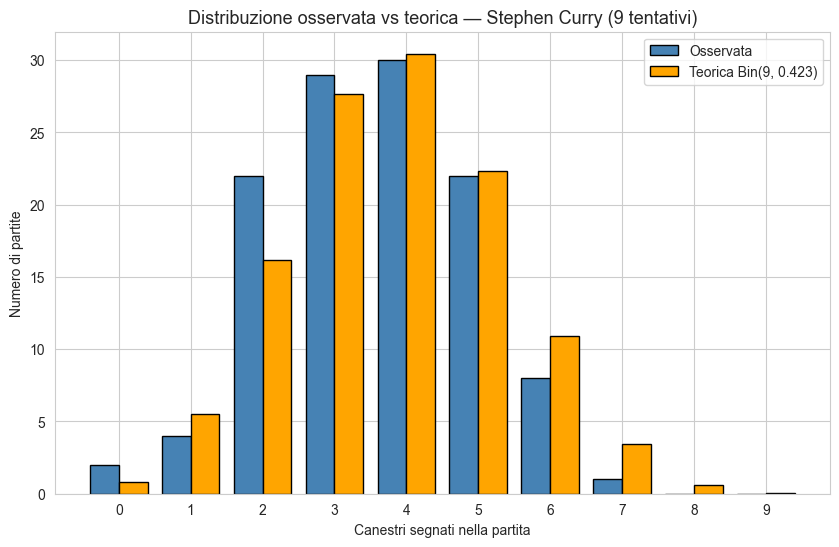

In [35]:
# Distribuzione osservata dei canestri
k_values = np.arange(0, n_fix + 1)
observed = np.array([(games_n['canestri'] == k).sum() for k in k_values])

# Distribuzione teorica Binomiale(n_fix, p_player)
theoretical = stats.binom.pmf(k_values, n_fix, p_player) * len(games_n)

# Grafico di confronto
fig, ax = plt.subplots()
width = 0.4
ax.bar(k_values - width/2, observed, width=width, label='Osservata', color='steelblue', edgecolor='black')
ax.bar(k_values + width/2, theoretical, width=width, label=f'Teorica Bin({n_fix}, {p_player:.3f})', color='orange', edgecolor='black')
ax.set_xlabel('Canestri segnati nella partita')
ax.set_ylabel('Numero di partite')
ax.set_title(f'Distribuzione osservata vs teorica — {top_player} ({n_fix} tentativi)')
ax.set_xticks(k_values)
ax.legend()
plt.show()

### Passiamo al passo successivo

Il modello binomiale approssima bene i dati reali: possiamo quindi trattare con sicurezza ogni tiro come una Bernoulli. Ora che sappiamo *come* modellare il tiro, torniamo alla domanda di ricerca e facciamo un primo confronto descrittivo: **qual è la percentuale da 3 nei primi tre quarti rispetto al 4° quarto e ai momenti clutch?**

## 3. Confronto descrittivo: Q1-Q3 vs Q4 vs Clutch

Calcoliamo la percentuale realizzativa da 3 punti per quarto su tutta la NBA. Definiamo *clutch time* un tiro tentato nel 4° quarto con meno di 2 minuti rimasti (`MINS_LEFT < 2`).

In [36]:
# Consideriamo solo i quarti regolari (1-4), escludendo i supplementari
df_reg = df_3pt[df_3pt['QUARTER'].between(1, 4)].copy()

# Percentuale per quarto
pct_per_quarter = df_reg.groupby('QUARTER')['SHOT_MADE'].mean() * 100
n_per_quarter = df_reg.groupby('QUARTER')['SHOT_MADE'].count()

for q in pct_per_quarter.index:
    print(f"Quarto {q}: {pct_per_quarter[q]:.2f}% (n = {n_per_quarter[q]:,})")

Quarto 1: 36.98% (n = 311,481)
Quarto 2: 35.71% (n = 318,918)
Quarto 3: 36.35% (n = 323,252)
Quarto 4: 34.55% (n = 335,134)


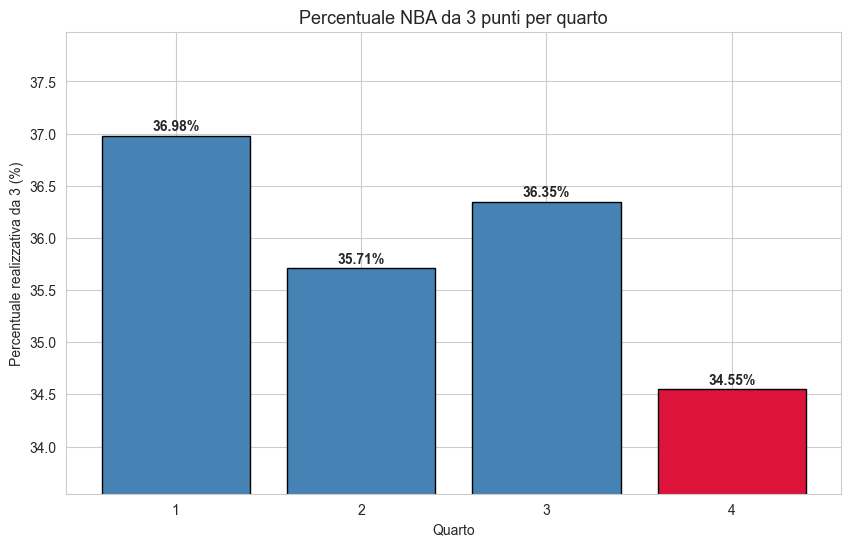

In [37]:
# Bar chart: percentuale da 3 per quarto
fig, ax = plt.subplots()
colors = ['steelblue', 'steelblue', 'steelblue', 'crimson']
ax.bar(pct_per_quarter.index.astype(str), pct_per_quarter.values, color=colors, edgecolor='black')
ax.set_xlabel('Quarto')
ax.set_ylabel('Percentuale realizzativa da 3 (%)')
ax.set_title('Percentuale NBA da 3 punti per quarto')
ax.set_ylim(pct_per_quarter.min() - 1, pct_per_quarter.max() + 1)
for i, v in enumerate(pct_per_quarter.values):
    ax.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')
plt.show()

In [38]:
# Confronto: primi 3 quarti vs 4° quarto vs clutch time
mask_q13 = df_reg['QUARTER'] <= 3
mask_q4 = df_reg['QUARTER'] == 4
mask_clutch = (df_reg['QUARTER'] == 4) & (df_reg['MINS_LEFT'] < 2)

pct_q13 = df_reg.loc[mask_q13, 'SHOT_MADE'].mean() * 100
pct_q4 = df_reg.loc[mask_q4, 'SHOT_MADE'].mean() * 100
pct_clutch = df_reg.loc[mask_clutch, 'SHOT_MADE'].mean() * 100

n_q13 = mask_q13.sum()
n_q4 = mask_q4.sum()
n_clutch = mask_clutch.sum()

print(f"Q1-Q3:  {pct_q13:.2f}% (n = {n_q13:,})")
print(f"Q4:     {pct_q4:.2f}% (n = {n_q4:,})")
print(f"Clutch: {pct_clutch:.2f}% (n = {n_clutch:,})")
print(f"\nDifferenza Q1-Q3 vs Q4:     {pct_q13 - pct_q4:.3f} punti percentuali")
print(f"Differenza Q1-Q3 vs Clutch: {pct_q13 - pct_clutch:.3f} punti percentuali")

Q1-Q3:  36.34% (n = 953,651)
Q4:     34.55% (n = 335,134)
Clutch: 30.49% (n = 73,588)

Differenza Q1-Q3 vs Q4:     1.792 punti percentuali
Differenza Q1-Q3 vs Clutch: 5.845 punti percentuali


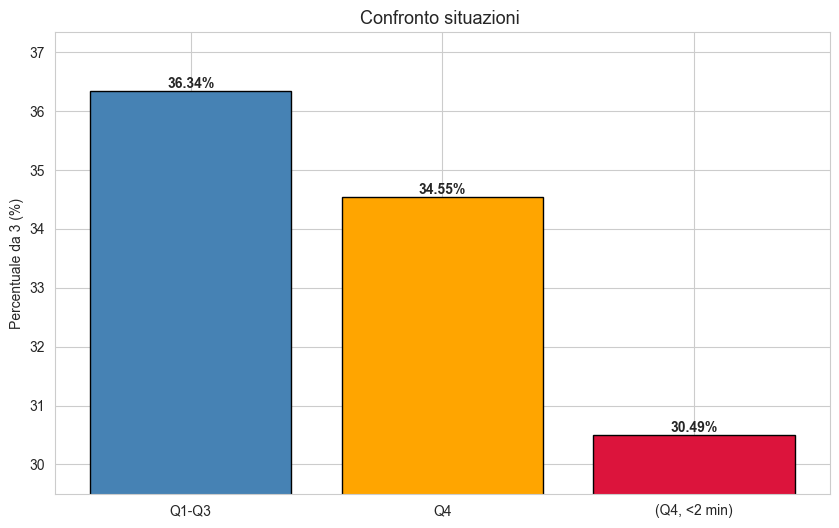

In [39]:
# Grafico del confronto
fig, ax = plt.subplots()
categorie = ['Q1-Q3', 'Q4', '(Q4, <2 min)']
valori = [pct_q13, pct_q4, pct_clutch]
colori = ['steelblue', 'orange', 'crimson']
ax.bar(categorie, valori, color=colori, edgecolor='black')
ax.set_ylabel('Percentuale da 3 (%)')
ax.set_title('Confronto situazioni ')
ax.set_ylim(min(valori) - 1, max(valori) + 1)
for i, v in enumerate(valori):
    ax.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')
plt.show()

### Passiamo al passo successivo

Abbiamo osservato una differenza concreta tra Q1-Q3, Q4 e clutch. Ma **come facciamo a sapere se questa differenza è reale o solo frutto del caso?** Prima di usare test di ipotesi e intervalli di confidenza, dobbiamo assicurarci che i nostri strumenti statistici siano giustificati. Due teoremi fondamentali ci servono:

- La **Legge dei Grandi Numeri (LGN)**, che garantisce che la percentuale osservata converga verso la vera probabilità $p$ al crescere dei tiri.
- Il **Teorema del Limite Centrale (TLC)**, che giustifica l'uso della distribuzione normale per costruire intervalli di confidenza e test.

Verifichiamoli entrambi sui nostri dati.

## 4. Legge dei Grandi Numeri

La LGN afferma che, all'aumentare del numero di prove $n$, la media campionaria $\bar{X}_n$ converge in probabilità al valore atteso $p$:

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \;\xrightarrow{P}\; p \quad \text{per } n \to \infty$$

Prendiamo i tiri del nostro giocatore nel 4° quarto in ordine cronologico e guardiamo come la media cumulativa si stabilizzi.

In [40]:
# Tiri del giocatore scelto solo nel 4° quarto, ordinati per data
player_q4 = df_reg[(df_reg['PLAYER_NAME'] == top_player) & (df_reg['QUARTER'] == 4)].copy()
player_q4 = player_q4.sort_values(['GAME_DATE', 'MINS_LEFT'], ascending=[True, False]).reset_index(drop=True)

# Media cumulativa tiro dopo tiro
player_q4['media_cumulativa'] = player_q4['SHOT_MADE'].expanding().mean()

p_finale = player_q4['SHOT_MADE'].mean()
print(f"Tiri totali nel Q4 di {top_player}: {len(player_q4):,}")
print(f"Percentuale finale (stima di p): {p_finale*100:.2f}%")

Tiri totali nel Q4 di Stephen Curry: 1,947
Percentuale finale (stima di p): 40.22%


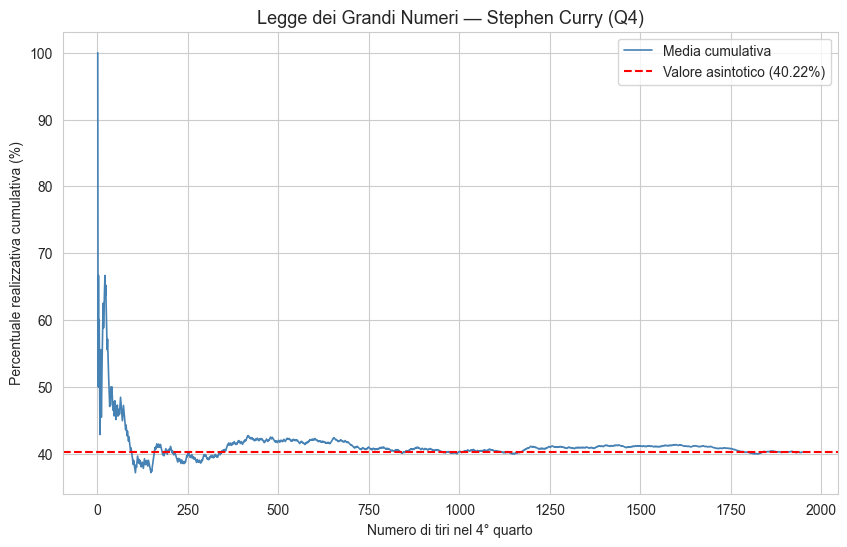

In [41]:
# Grafico della convergenza
fig, ax = plt.subplots()
ax.plot(np.arange(1, len(player_q4) + 1), player_q4['media_cumulativa'] * 100,
        color='steelblue', linewidth=1.2, label='Media cumulativa')
ax.axhline(p_finale * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Valore asintotico ({p_finale*100:.2f}%)')
ax.set_xlabel('Numero di tiri nel 4° quarto')
ax.set_ylabel('Percentuale realizzativa cumulativa (%)')
ax.set_title(f'Legge dei Grandi Numeri — {top_player} (Q4)')
ax.legend()
plt.show()

Ripetiamo lo stesso procedimento su tutti i tiri da 3 della NBA. Con milioni di tiri la convergenza è praticamente istantanea — la media si stabilizza quasi subito. Questo conferma che con il volume di dati del nostro dataset le stime sono estremamente affidabili.

Tiri da 3 totali nel dataset: 1,298,653
Percentuale finale (stima di p): 35.83%


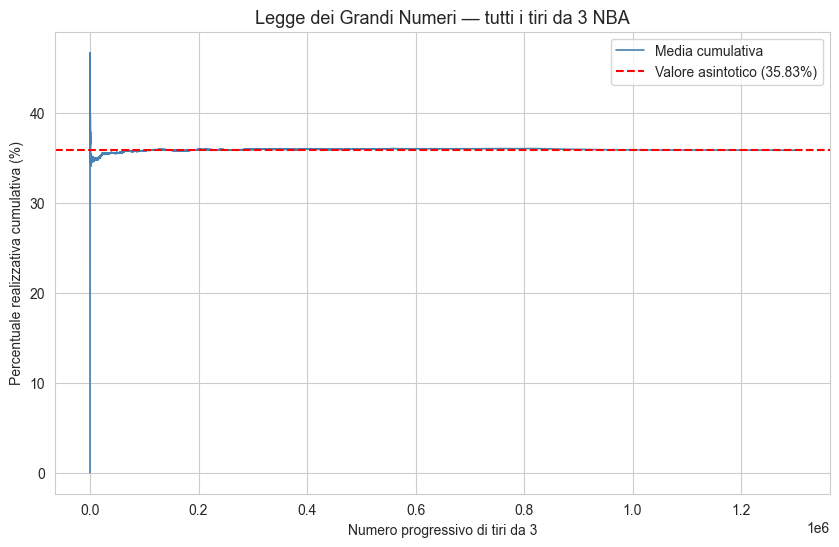

In [42]:
# Tutti i tiri da 3, ordinati cronologicamente
df_lgn = df_3pt.sort_values('GAME_DATE').reset_index(drop=True)
df_lgn['media_cumulativa'] = df_lgn['SHOT_MADE'].expanding().mean()

p_finale_nba = df_lgn['SHOT_MADE'].mean()
print(f'Tiri da 3 totali nel dataset: {len(df_lgn):,}')
print(f'Percentuale finale (stima di p): {p_finale_nba*100:.2f}%')

# Grafico — stesso stile del grafico di Curry
fig, ax = plt.subplots()
ax.plot(np.arange(1, len(df_lgn) + 1), df_lgn['media_cumulativa'] * 100,
        color='steelblue', linewidth=1.2, label='Media cumulativa')
ax.axhline(p_finale_nba * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Valore asintotico ({p_finale_nba*100:.2f}%)')
ax.set_xlabel('Numero progressivo di tiri da 3')
ax.set_ylabel('Percentuale realizzativa cumulativa (%)')
ax.set_title('Legge dei Grandi Numeri — tutti i tiri da 3 NBA')
ax.legend()
plt.show()


### Passiamo al passo successivo

La media cumulativa si stabilizza: la LGN è rispettata. Questo ci dice che, con il volume di tiri che abbiamo a disposizione, le stime delle percentuali sono affidabili.

Ma per costruire intervalli di confidenza e test di ipotesi serve un'altra cosa: conoscere la **distribuzione** della nostra stima. Qui entra in gioco il Teorema del Limite Centrale.

## 5. Teorema del Limite Centrale

Il TLC afferma che, data una variabile aleatoria qualsiasi con media $\mu$ e varianza finita $\sigma^2$, la distribuzione della media campionaria di $n$ osservazioni tende a una normale al crescere di $n$:

$$\bar{X}_n \;\xrightarrow{d}\; \mathcal{N}\!\left(\mu,\, \frac{\sigma^2}{n}\right)$$

Lo verifichiamo usando come popolazione di partenza le percentuali da 3 nel Q4 **partita per partita** (che non è affatto normale), e campionando medie su gruppi da 30 partite.

In [43]:
# Percentuale Q4 partita per partita (consideriamo solo partite con almeno 5 tiri da 3 nel Q4)
game_q4 = (df_reg[df_reg['QUARTER'] == 4]
           .groupby('GAME_ID')['SHOT_MADE']
           .agg(['mean', 'count'])
           .rename(columns={'mean': 'pct', 'count': 'tentativi'}))
game_q4 = game_q4[game_q4['tentativi'] >= 5]
print(f"Partite con almeno 5 tiri nel Q4: {len(game_q4):,}")
print(f"Media delle percentuali partita: {game_q4['pct'].mean()*100:.2f}%")
print(f"Deviazione standard: {game_q4['pct'].std()*100:.2f}%")

Partite con almeno 5 tiri nel Q4: 25,749
Media delle percentuali partita: 34.31%
Deviazione standard: 13.94%


In [44]:
# Campioniamo 5000 gruppi da 30 partite e calcoliamo la media di ciascun gruppo
np.random.seed(42)
num_campioni = 5000
dim_campione = 30
medie_campionarie = np.array([
    game_q4['pct'].sample(dim_campione, replace=True).mean()
    for _ in range(num_campioni)
])

print(f"Media delle medie: {medie_campionarie.mean()*100:.2f}%")
print(f"Deviazione standard delle medie: {medie_campionarie.std()*100:.2f}%")
print(f"Atteso dal TLC (sigma/sqrt(n)): {game_q4['pct'].std()/np.sqrt(dim_campione)*100:.2f}%")

Media delle medie: 34.28%
Deviazione standard delle medie: 2.53%
Atteso dal TLC (sigma/sqrt(n)): 2.54%


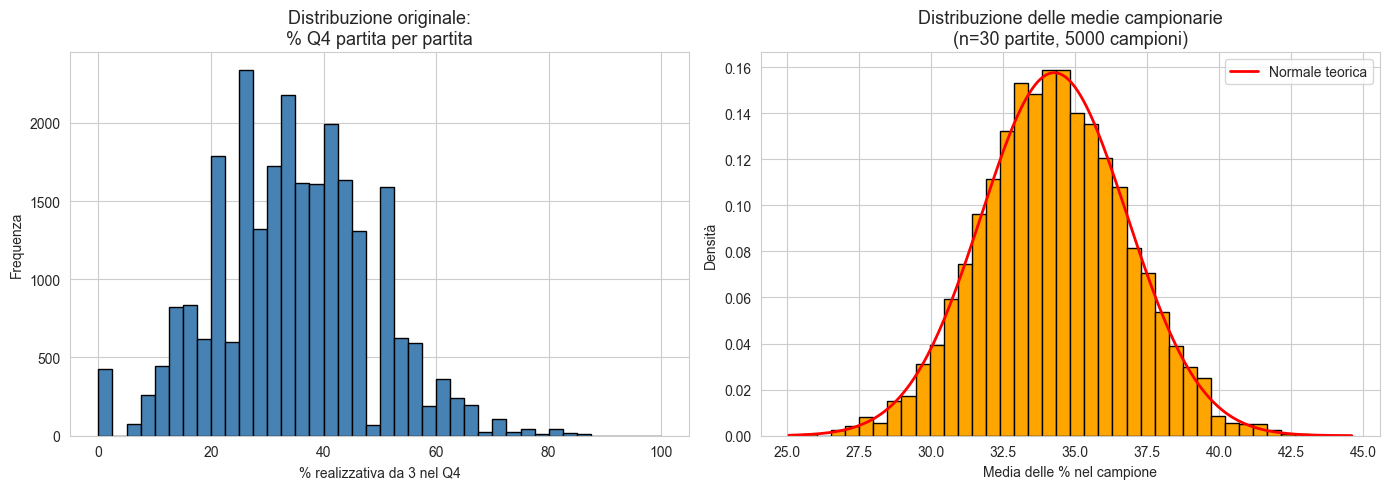

In [45]:
# Confronto visivo tra distribuzione originale e distribuzione delle medie campionarie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuzione originale (non normale)
axes[0].hist(game_q4['pct'] * 100, bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribuzione originale:\n% Q4 partita per partita')
axes[0].set_xlabel('% realizzativa da 3 nel Q4')
axes[0].set_ylabel('Frequenza')

# Distribuzione delle medie campionarie (dovrebbe essere ~ normale)
axes[1].hist(medie_campionarie * 100, bins=40, color='orange', edgecolor='black', density=True)
mu = medie_campionarie.mean() * 100
sigma = medie_campionarie.std() * 100
x_grid = np.linspace(medie_campionarie.min()*100, medie_campionarie.max()*100, 200)
axes[1].plot(x_grid, stats.norm.pdf(x_grid, mu, sigma), 'r-', linewidth=2, label='Normale teorica')
axes[1].set_title(f'Distribuzione delle medie campionarie\n(n={dim_campione} partite, {num_campioni} campioni)')
axes[1].set_xlabel('Media delle % nel campione')
axes[1].set_ylabel('Densità')
axes[1].legend()

plt.tight_layout()
plt.show()

### Passiamo al passo successivo

Anche partendo da una distribuzione non normale, le medie campionarie si distribuiscono approssimativamente come una normale: il TLC vale. Ora abbiamo tutte le carte in regola per quantificare l'incertezza delle nostre stime tramite **intervalli di confidenza**.

## 6. Intervalli di confidenza

Un intervallo di confidenza al 95% per una proporzione $p$ stimata come $\hat{p}$ è:

$$\hat{p} \pm z_{0.975}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}} \quad \text{se } n > 100$$

Se $n$ è piccolo usiamo invece il quantile della distribuzione $t$ di Student con $n-1$ gradi di libertà.

Calcoliamo gli IC al 95% per Q1-Q3 e Q4 per i 10 giocatori con più tiri da 3 nel dataset.

In [46]:
# Selezioniamo i 10 giocatori con più tiri da 3
top10 = df_reg['PLAYER_NAME'].value_counts().head(10).index.tolist()

risultati = []
for player in top10:
    tiri_p = df_reg[df_reg['PLAYER_NAME'] == player]
    
    # Q1-Q3
    q13 = tiri_p[tiri_p['QUARTER'] <= 3]['SHOT_MADE']
    n1, p1 = len(q13), q13.mean()
    se1 = np.sqrt(p1 * (1 - p1) / n1)
    z_or_t1 = 1.96 if n1 > 100 else stats.t.ppf(0.975, n1 - 1)
    margine1 = z_or_t1 * se1
    
    # Q4
    q4 = tiri_p[tiri_p['QUARTER'] == 4]['SHOT_MADE']
    n2, p2 = len(q4), q4.mean()
    se2 = np.sqrt(p2 * (1 - p2) / n2)
    z_or_t2 = 1.96 if n2 > 100 else stats.t.ppf(0.975, n2 - 1)
    margine2 = z_or_t2 * se2
    
    risultati.append({
        'giocatore': player,
        'p_q13': p1, 'margine_q13': margine1, 'n_q13': n1,
        'p_q4': p2, 'margine_q4': margine2, 'n_q4': n2
    })

res_df = pd.DataFrame(risultati)
res_df[['giocatore', 'p_q13', 'margine_q13', 'p_q4', 'margine_q4']].round(4)

,giocatore,p_q13,margine_q13,p_q4,margine_q4
0,Stephen Curry,0.4286,0.0112,0.4022,0.0218
1,James Harden,0.3682,0.0115,0.3453,0.0209
2,Damian Lillard,0.3786,0.0126,0.3495,0.0219
3,LeBron James,0.3574,0.0131,0.3313,0.0202
4,Klay Thompson,0.4190,0.0136,0.3889,0.0251
5,Paul George,0.3938,0.0140,0.3495,0.0250
6,Kyle Lowry,0.3723,0.0141,0.3573,0.0252
7,Jamal Crawford,0.3479,0.0144,0.3497,0.0226
8,Kyle Korver,0.4354,0.0156,0.4168,0.0230
9,Eric Gordon,0.3809,0.0145,0.3412,0.0261


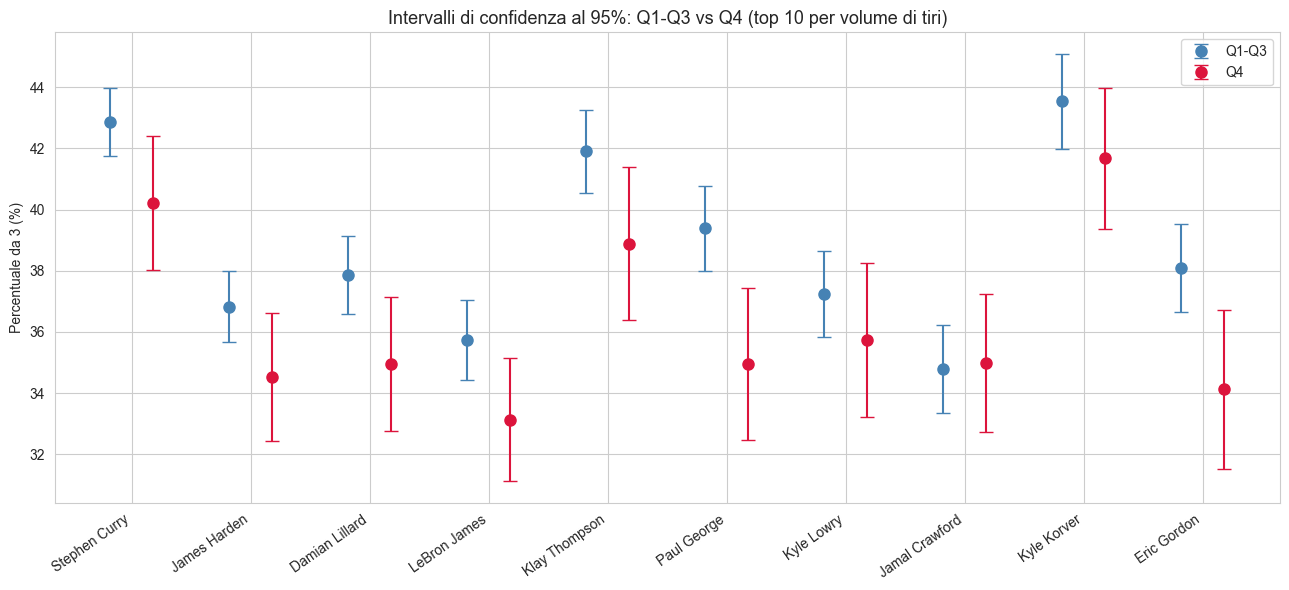

In [47]:
# Grafico con barre d'errore
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(res_df))
offset = 0.18

ax.errorbar(x - offset, res_df['p_q13'] * 100, yerr=res_df['margine_q13'] * 100,
            fmt='o', capsize=5, color='steelblue', label='Q1-Q3', markersize=8)
ax.errorbar(x + offset, res_df['p_q4'] * 100, yerr=res_df['margine_q4'] * 100,
            fmt='o', capsize=5, color='crimson', label='Q4', markersize=8)

ax.set_xticks(x)
ax.set_xticklabels(res_df['giocatore'], rotation=35, ha='right')
ax.set_ylabel('Percentuale da 3 (%)')
ax.set_title('Intervalli di confidenza al 95%: Q1-Q3 vs Q4 (top 10 per volume di tiri)')
ax.legend()
plt.tight_layout()
plt.show()

### Passiamo al passo successivo

Gli intervalli di confidenza ci dicono *quanto* siamo certi delle nostre stime, ma non rispondono formalmente alla domanda: **la differenza Q1-Q3 vs Q4 è statisticamente significativa?** Per rispondere usiamo un test di ipotesi.

## 7. Test di ipotesi

Formalizziamo ora la domanda di ricerca come un test statistico. Condurremo **tre test**:

1. **Z-test bilaterale** sulla differenza di proporzioni Q1-Q3 vs Q4 per tutta la NBA.
2. **Z-test unilaterale** sulla stessa differenza, per verificare la direzione del calo.
3. **t-test unilaterale** su un singolo giocatore, usando le percentuali partita per partita.

Per tutti i test fissiamo il **livello di significatività** $\alpha = 0.05$.

### 7.1 Test 1 — Z-test bilaterale su tutta la NBA

**Ipotesi (in parole).**
- $H_0$: la probabilità di segnare da 3 nel 4° quarto è **uguale** a quella nei primi tre quarti.
- $H_1$: le due probabilità sono **diverse** (senza specificare in quale direzione).

**Ipotesi (in formula).**
$$H_0: p_{Q4} = p_{Q1\text{-}Q3} \qquad H_1: p_{Q4} \neq p_{Q1\text{-}Q3}$$

**Livello di significatività.** $\alpha = 0.05$.

**Tipo di test: bilaterale.** Non assumiamo a priori la direzione della differenza: vogliamo solo sapere se esiste una differenza in un senso o nell'altro. La regione di rifiuto è quindi nelle **due code** della distribuzione.

**Statistica test: Z.** Stiamo confrontando due proporzioni con campioni enormi ($n_1, n_2 \gg 30$, centinaia di migliaia di tiri ciascuno). Per il TLC la statistica standardizzata è approssimativamente normale, quindi usiamo Z (non t, che serve quando $n$ è piccolo o quando abbiamo una stima rumorosa della varianza). Sotto $H_0$ la proporzione comune è stimata come *pooled*:

$$\hat{p} = \frac{X_{Q1\text{-}Q3} + X_{Q4}}{n_1 + n_2}, \qquad Z = \frac{\hat{p}_{Q4} - \hat{p}_{Q1\text{-}Q3}}{\sqrt{\hat{p}(1-\hat{p})\left(\tfrac{1}{n_1}+\tfrac{1}{n_2}\right)}}$$

**Regione di rifiuto.** Rifiutiamo $H_0$ se $|Z| > z_{1-\alpha/2} = z_{0.975} \approx 1.96$.

In [48]:
# Dati sulle due popolazioni
q13_all = df_reg[df_reg['QUARTER'] <= 3]['SHOT_MADE']
q4_all = df_reg[df_reg['QUARTER'] == 4]['SHOT_MADE']

n1, n2 = len(q13_all), len(q4_all)
succ1, succ2 = int(q13_all.sum()), int(q4_all.sum())
p1, p2 = succ1 / n1, succ2 / n2

# Proporzione pooled sotto H0 e errore standard
p_pool = (succ1 + succ2) / (n1 + n2)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))

# Statistica Z
z_stat = (p2 - p1) / se_pool

# Valore critico bilaterale al 5%
alpha = 0.05
z_crit_bi = stats.norm.ppf(1 - alpha/2)

# p-value bilaterale
p_value_bi = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print('--- TEST 1: Z-test bilaterale (tutta la NBA) ---')
print(f'Q1-Q3: p_hat = {p1*100:.4f}%   (n = {n1:,})')
print(f'Q4:    p_hat = {p2*100:.4f}%   (n = {n2:,})')
print(f'Differenza (Q4 - Q1-Q3): {(p2 - p1)*100:.4f} punti percentuali')
print()
print(f'Statistica test Z = {z_stat:.4f}')
print(f'Valore critico (alpha=0.05, bilaterale): ±{z_crit_bi:.4f}')
print(f'Regione di rifiuto: |Z| > {z_crit_bi:.4f}')
print(f'p-value bilaterale: {p_value_bi:.3e}')
print()
if abs(z_stat) > z_crit_bi:
    print(f'CONCLUSIONE: Rifiutiamo H0 perché |Z| = {abs(z_stat):.4f} > {z_crit_bi:.4f}')
    print(f'(equivalente: p-value = {p_value_bi:.3e} < alpha = 0.05).')
    print('La differenza tra Q1-Q3 e Q4 NON è compatibile con il caso.')
else:
    print(f'CONCLUSIONE: Non rifiutiamo H0 perché |Z| = {abs(z_stat):.4f} <= {z_crit_bi:.4f}')

--- TEST 1: Z-test bilaterale (tutta la NBA) ---
Q1-Q3: p_hat = 36.3392%   (n = 953,651)
Q4:    p_hat = 34.5474%   (n = 335,134)
Differenza (Q4 - Q1-Q3): -1.7918 punti percentuali

Statistica test Z = -18.6038
Valore critico (alpha=0.05, bilaterale): ±1.9600
Regione di rifiuto: |Z| > 1.9600
p-value bilaterale: 0.000e+00

CONCLUSIONE: Rifiutiamo H0 perché |Z| = 18.6038 > 1.9600
(equivalente: p-value = 0.000e+00 < alpha = 0.05).
La differenza tra Q1-Q3 e Q4 NON è compatibile con il caso.


### 7.2–7.3 Analisi disaggregata: il calo nel Q4 è uniforme?

Il test precedente ha mostrato che **tutta la NBA** tira peggio nel Q4. Ma questo calo riguarda tutti allo stesso modo, o ci sono sottogruppi che resistono meglio?

Estendiamo l'analisi con **due test aggiuntivi**, identici nello schema al Test 2 (Z-test unilaterale sinistro, $\alpha = 0.05$), applicati però a sottoinsiemi diversi dei dati:

1. **Test 2** — *per zona di campo*: il calo è più marcato dai tiri dall'angolo o dal centro?
2. **Test 3** — *per volume di tiro*: i tiratori ad alto volume calano meno dei tiratori occasionali?

### 7.2 Test 2 — Z-test unilaterale per zona di campo

**Domanda.** Il calo nel Q4 dipende da *dove* si tira? I tiri dall'angolo (*corner three*: `Left Corner 3`, `Right Corner 3`) e i tiri dal centro (*above-the-break*: `Above the Break 3`) potrebbero rispondere diversamente alla pressione e alla stanchezza del Q4.

**Ipotesi (identiche per entrambe le zone, test unilaterale sinistro).**
- $H_0$: $p_{Q4} \geq p_{Q1\text{-}Q3}$ — la percentuale nel Q4 non scende rispetto ai primi tre quarti.
- $H_1$: $p_{Q4} < p_{Q1\text{-}Q3}$ — la percentuale nel Q4 è significativamente più bassa.

**Statistica test e regione di rifiuto.** Stessa formula Z del Test 1 con proporzione *pooled*. Rifiutiamo $H_0$ se $Z < -z_{0.95} \approx -1.645$.

**Confronto finale.** Guardando la statistica Z per le due zone, un Z più negativo indica un calo *più marcato* in quella zona.

--- TEST 3: Z-test unilaterale per zona di campo ---

  Zona: Angolo (Corner 3)
    Q1-Q3: 39.296%  (n=243,808)
    Q4:    37.193%  (n=83,714)
    Diff:  -2.102 pp
    Z = -10.7723  |  p-value = 2.3272e-27  →  RIFIUTO H0

  Zona: Centro (Above the Break 3)
    Q1-Q3: 35.732%  (n=700,139)
    Q4:    33.732%  (n=250,593)
    Diff:  -1.999 pp
    Z = -17.9820  |  p-value = 1.3471e-72  →  RIFIUTO H0

Valore critico (unilaterale sinistro, alpha=0.05): -1.6449

Il calo più marcato si osserva nei tiri: Centro (Above the Break 3) (Z = -17.9820)


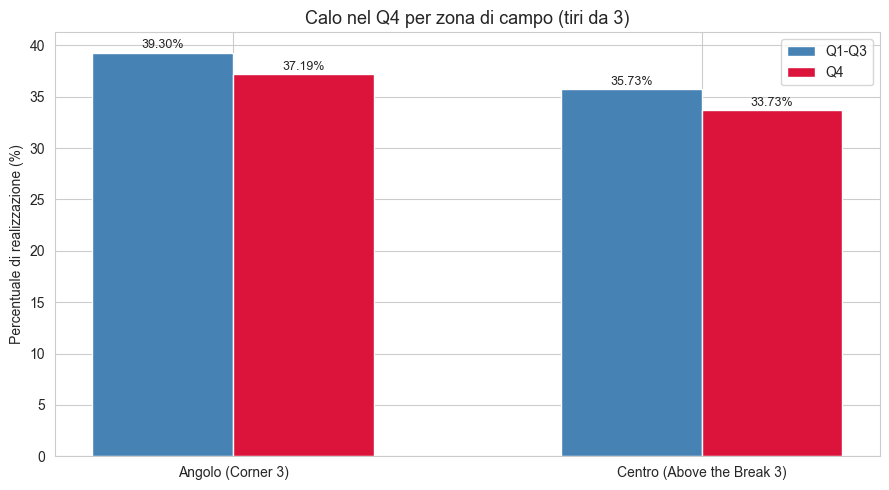

In [50]:
# Definiamo le due zone di interesse
mask_corner = df_reg['BASIC_ZONE'].isin(['Left Corner 3', 'Right Corner 3'])
mask_center = df_reg['BASIC_ZONE'] == 'Above the Break 3'

def z_test_unilaterale(df_zona, nome_zona):
    """Z-test unilaterale sinistro Q1-Q3 vs Q4 su un sottoinsieme del dataset."""
    q13 = df_zona[df_zona['QUARTER'] <= 3]['SHOT_MADE']
    q4  = df_zona[df_zona['QUARTER'] == 4]['SHOT_MADE']
    n1, n2 = len(q13), len(q4)
    p1, p2 = q13.mean(), q4.mean()
    p_pool = (q13.sum() + q4.sum()) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z = (p2 - p1) / se
    pv = stats.norm.cdf(z)   # p-value unilaterale sinistro
    return {'zona': nome_zona, 'p_q13': p1, 'p_q4': p2,
            'diff_pp': (p2 - p1) * 100, 'Z': z, 'p_value': pv,
            'n_q13': n1, 'n_q4': n2}

res_corner = z_test_unilaterale(df_reg[mask_corner], 'Angolo (Corner 3)')
res_center = z_test_unilaterale(df_reg[mask_center], 'Centro (Above the Break 3)')

z_crit_uni = stats.norm.ppf(1 - alpha)   # ~1.645

print('--- TEST 2: Z-test unilaterale per zona di campo ---')
for r in [res_corner, res_center]:
    esito = 'RIFIUTO H0' if r['Z'] < -z_crit_uni else 'non rifiuto H0'
    print(f"\n  Zona: {r['zona']}")
    print(f"    Q1-Q3: {r['p_q13']*100:.3f}%  (n={r['n_q13']:,})")
    print(f"    Q4:    {r['p_q4']*100:.3f}%  (n={r['n_q4']:,})")
    print(f"    Diff:  {r['diff_pp']:+.3f} pp")
    print(f"    Z = {r['Z']:.4f}  |  p-value = {r['p_value']:.4e}  →  {esito}")

print(f"\nValore critico (unilaterale sinistro, alpha=0.05): -{z_crit_uni:.4f}")
piu_marcato = res_corner if res_corner['Z'] < res_center['Z'] else res_center
print(f"\nIl calo più marcato si osserva nei tiri: {piu_marcato['zona']} (Z = {piu_marcato['Z']:.4f})")

# Grafico
fig, ax = plt.subplots(figsize=(9, 5))
zone_nomi  = [res_corner['zona'], res_center['zona']]
pct_q13    = [res_corner['p_q13']*100, res_center['p_q13']*100]
pct_q4     = [res_corner['p_q4']*100,  res_center['p_q4']*100]
x = np.arange(len(zone_nomi))
w = 0.3
b1 = ax.bar(x - w/2, pct_q13, w, label='Q1-Q3', color='steelblue')
b2 = ax.bar(x + w/2, pct_q4,  w, label='Q4',    color='crimson')
ax.set_xticks(x); ax.set_xticklabels(zone_nomi)
ax.set_ylabel('Percentuale di realizzazione (%)')
ax.set_title('Calo nel Q4 per zona di campo (tiri da 3)')
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{h:.2f}%',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 7.3 Test 3 — Z-test unilaterale per volume di tiro del giocatore

**Domanda.** I giocatori abituati a tirare molto da 3 — e quindi più allenati a reggere la pressione negli istanti finali — calano meno nel Q4 rispetto ai tiratori occasionali?

**Definizione dei gruppi.**
Calcoliamo il numero totale di tiri da 3 tentati da ciascun giocatore nel dataset. Classifichiamo come *alto volume* i giocatori nel **top 25%** per numero di tentativi, e come *basso volume* quelli nel **bottom 25%**. I due quarti centrali (50%) vengono esclusi per rendere il confronto netto.

**Ipotesi (identiche per entrambi i gruppi, test unilaterale sinistro).**
- $H_0$: $p_{Q4} \geq p_{Q1\text{-}Q3}$ — la percentuale nel Q4 non scende.
- $H_1$: $p_{Q4} < p_{Q1\text{-}Q3}$ — la percentuale nel Q4 è significativamente più bassa.

**Statistica test e regione di rifiuto.** Stessa formula Z dei test precedenti. Rifiutiamo $H_0$ se $Z < -1.645$.

**Confronto finale.** Se il gruppo ad alto volume mostra uno Z meno negativo (o non significativo), avremmo evidenza che l'esperienza attenua il calo.

Soglia alto volume (75°p): >= 739 tiri da 3  (525 giocatori)
Soglia basso volume (25°p): <= 16 tiri da 3  (531 giocatori)

--- TEST 4: Z-test unilaterale per volume di tiro ---

  Gruppo: Alto volume (top 25%)
    Q1-Q3: 36.982%  (n=808,080)
    Q4:    35.193%  (n=269,690)
    Diff:  -1.789 pp
    Z = -16.7110  |  p-value = 5.4515e-63  →  RIFIUTO H0

  Gruppo: Basso volume (bottom 25%)
    Q1-Q3: 17.636%  (n=1,565)
    Q4:    22.033%  (n=1,643)
    Diff:  +4.397 pp
    Z = 3.1188  |  p-value = 9.9909e-01  →  non rifiuto H0

Valore critico (unilaterale sinistro, alpha=0.05): -1.6449

I tiratori ad alto volume non mostrano un calo apprezzabilmente minore nel Q4.


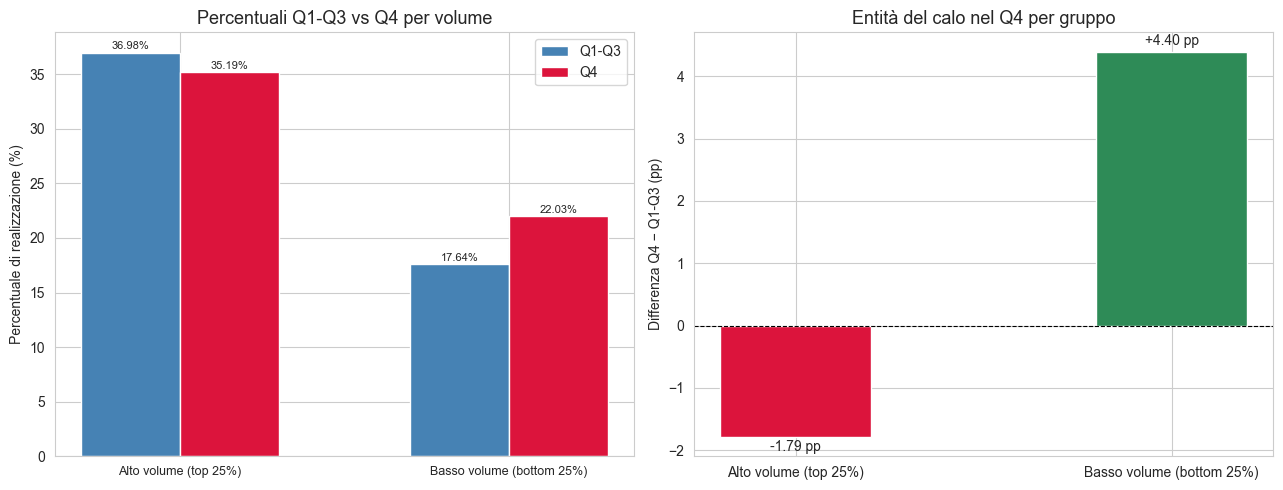

In [51]:
# Volume totale di tiri da 3 per giocatore (su tutto il dataset)
vol_per_player = df_reg.groupby('PLAYER_NAME').size()
q25 = vol_per_player.quantile(0.25)
q75 = vol_per_player.quantile(0.75)

hi_vol_players  = vol_per_player[vol_per_player >= q75].index
lo_vol_players  = vol_per_player[vol_per_player <= q25].index

df_hi = df_reg[df_reg['PLAYER_NAME'].isin(hi_vol_players)]
df_lo = df_reg[df_reg['PLAYER_NAME'].isin(lo_vol_players)]

print(f'Soglia alto volume (75°p): >= {q75:.0f} tiri da 3  ({len(hi_vol_players):,} giocatori)')
print(f'Soglia basso volume (25°p): <= {q25:.0f} tiri da 3  ({len(lo_vol_players):,} giocatori)')
print()

res_hi = z_test_unilaterale(df_hi, 'Alto volume (top 25%)')
res_lo = z_test_unilaterale(df_lo, 'Basso volume (bottom 25%)')

print('--- TEST 3: Z-test unilaterale per volume di tiro ---')
for r in [res_hi, res_lo]:
    esito = 'RIFIUTO H0' if r['Z'] < -z_crit_uni else 'non rifiuto H0'
    print(f"\n  Gruppo: {r['zona']}")
    print(f"    Q1-Q3: {r['p_q13']*100:.3f}%  (n={r['n_q13']:,})")
    print(f"    Q4:    {r['p_q4']*100:.3f}%  (n={r['n_q4']:,})")
    print(f"    Diff:  {r['diff_pp']:+.3f} pp")
    print(f"    Z = {r['Z']:.4f}  |  p-value = {r['p_value']:.4e}  →  {esito}")

print(f"\nValore critico (unilaterale sinistro, alpha=0.05): -{z_crit_uni:.4f}")
delta_hi = res_hi['diff_pp']
delta_lo = res_lo['diff_pp']
if delta_hi > delta_lo:
    print('\nI tiratori ad alto volume mostrano un calo MINORE nel Q4: esperienza come fattore protettivo.')
else:
    print('\nI tiratori ad alto volume non mostrano un calo apprezzabilmente minore nel Q4.')

# Grafico
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sinistra: barre percentuali Q1-Q3 vs Q4
gruppi    = [res_hi['zona'], res_lo['zona']]
pct_q13_v = [res_hi['p_q13']*100, res_lo['p_q13']*100]
pct_q4_v  = [res_hi['p_q4']*100,  res_lo['p_q4']*100]
x = np.arange(len(gruppi))
b1 = axes[0].bar(x - w/2, pct_q13_v, w, label='Q1-Q3', color='steelblue')
b2 = axes[0].bar(x + w/2, pct_q4_v,  w, label='Q4',    color='crimson')
axes[0].set_xticks(x); axes[0].set_xticklabels(gruppi, fontsize=9)
axes[0].set_ylabel('Percentuale di realizzazione (%)')
axes[0].set_title('Percentuali Q1-Q3 vs Q4 per volume')
axes[0].legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{h:.2f}%',
                 ha='center', va='bottom', fontsize=8)

# Destra: calo in punti percentuali (differenza Q4 - Q1-Q3)
cali = [delta_hi, delta_lo]
colori_calo = ['seagreen' if c > -1 else 'crimson' for c in cali]
axes[1].bar(gruppi, cali, color=colori_calo, width=0.4)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Differenza Q4 − Q1-Q3 (pp)')
axes[1].set_title('Entità del calo nel Q4 per gruppo')
for idx, v in enumerate(cali):
    axes[1].text(idx, v - 0.05 if v < 0 else v + 0.05,
                 f'{v:+.2f} pp', ha='center', va='top' if v < 0 else 'bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 7.4 Test 4 — Z-test unilaterale: Q4 non-clutch vs Clutch

**Domanda.** Sappiamo già che il Q4 è peggiore dei primi tre quarti. Ma *all'interno* del Q4 si nasconde un’ulteriore frattura? Gli ultimi 2 minuti di partita — quelli ad altissima pressione, dove ogni possesso conta — trascinano la percentuale ancora più in basso rispetto al resto del quarto finale?

**Definizione dei gruppi.**
Consideriamo solo i tiri da 3 del Q4 e li dividiamo in:
- *Q4 non-clutch*: `QUARTER == 4` e `MINS_LEFT >= 2` — il Q4 “normale”.
- *Clutch*: `QUARTER == 4` e `MINS_LEFT < 2` — gli ultimi 2 minuti.

**Ipotesi.**
- $H_0$: $p_{\text{clutch}} \geq p_{\text{Q4\_nc}}$ — nel clutch non si tira peggio del resto del Q4.
- $H_1$: $p_{\text{clutch}} < p_{\text{Q4\_nc}}$ — nel clutch la percentuale scende ulteriormente.

**Livello di significatività.** $\alpha = 0.05$.

**Tipo di test: Z unilaterale sinistro.** Stesso schema dei test precedenti: campioni grandi, proporzione *pooled* sotto $H_0$, regione di rifiuto $Z < -z_{0.95} \approx -1.645$.

--- TEST 5: Z-test unilaterale sinistro (Q4 non-clutch vs Clutch) ---
Q4 non-clutch (MINS_LEFT >= 2): p_hat = 35.6878%  (n = 261,546)
Clutch        (MINS_LEFT <  2): p_hat = 30.4941%  (n = 73,588)
Differenza (clutch - Q4_nc):    -5.1937 pp

Statistica test Z  = -26.1742
Valore critico     = -1.6449  (alpha=0.05, unilaterale sinistro)
Regione di rifiuto : Z < -1.6449
p-value            = 2.6136e-151

CONCLUSIONE: Rifiutiamo H0 (Z = -26.1742 < -1.6449).
Nel clutch la percentuale da 3 scende significativamente rispetto al resto del Q4.


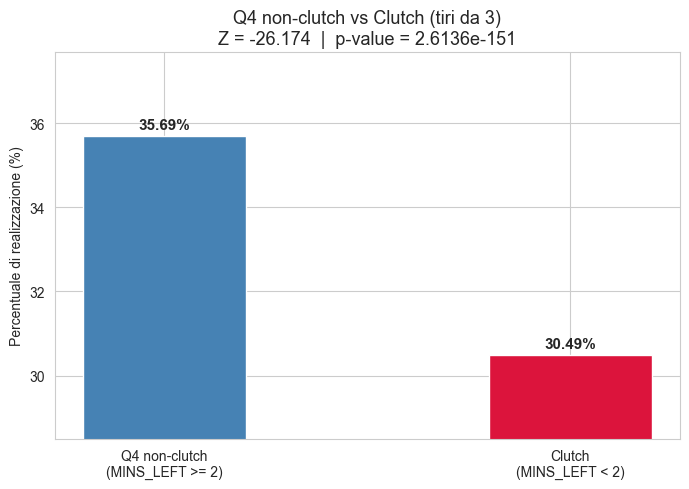

In [52]:
# Dividiamo i tiri da 3 del Q4 in non-clutch e clutch
q4_nc   = df_reg[(df_reg['QUARTER'] == 4) & (df_reg['MINS_LEFT'] >= 2)]['SHOT_MADE']
q4_cl   = df_reg[(df_reg['QUARTER'] == 4) & (df_reg['MINS_LEFT'] <  2)]['SHOT_MADE']

n_nc, n_cl   = len(q4_nc), len(q4_cl)
p_nc, p_cl   = q4_nc.mean(), q4_cl.mean()
p_pool_5     = (q4_nc.sum() + q4_cl.sum()) / (n_nc + n_cl)
se_5         = np.sqrt(p_pool_5 * (1 - p_pool_5) * (1/n_nc + 1/n_cl))
z_5          = (p_cl - p_nc) / se_5
pv_5         = stats.norm.cdf(z_5)   # p-value unilaterale sinistro

print('--- TEST 4: Z-test unilaterale sinistro (Q4 non-clutch vs Clutch) ---')
print(f'Q4 non-clutch (MINS_LEFT >= 2): p_hat = {p_nc*100:.4f}%  (n = {n_nc:,})')
print(f'Clutch        (MINS_LEFT <  2): p_hat = {p_cl*100:.4f}%  (n = {n_cl:,})')
print(f'Differenza (clutch - Q4_nc):    {(p_cl - p_nc)*100:+.4f} pp')
print()
print(f'Statistica test Z  = {z_5:.4f}')
print(f'Valore critico     = -{z_crit_uni:.4f}  (alpha=0.05, unilaterale sinistro)')
print(f'Regione di rifiuto : Z < -{z_crit_uni:.4f}')
print(f'p-value            = {pv_5:.4e}')
print()
if z_5 < -z_crit_uni:
    print(f'CONCLUSIONE: Rifiutiamo H0 (Z = {z_5:.4f} < -{z_crit_uni:.4f}).')
    print('Nel clutch la percentuale da 3 scende significativamente rispetto al resto del Q4.')
else:
    print(f'CONCLUSIONE: Non rifiutiamo H0 (Z = {z_5:.4f} >= -{z_crit_uni:.4f}).')
    print('Non vi e\' evidenza sufficiente di un ulteriore calo negli ultimi 2 minuti.')

# Grafico
fig, ax = plt.subplots(figsize=(7, 5))
gruppi_5 = ['Q4 non-clutch\n(MINS_LEFT >= 2)', 'Clutch\n(MINS_LEFT < 2)']
pct_5    = [p_nc * 100, p_cl * 100]
colori_5 = ['steelblue', 'crimson']
bars = ax.bar(gruppi_5, pct_5, color=colori_5, width=0.4)
ax.set_ylabel('Percentuale di realizzazione (%)')
ax.set_title(
    f'Q4 non-clutch vs Clutch (tiri da 3)\n'
    f'Z = {z_5:.3f}  |  p-value = {pv_5:.4e}'
)
y_min = min(pct_5) - 2
ax.set_ylim(y_min, max(pct_5) + 2)
for bar, v in zip(bars, pct_5):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1,
            f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.5 Errori di Tipo I e Tipo II: cosa significherebbe sbagliare qui?

Ogni test di ipotesi ha due modi di sbagliare:

| | Realtà: $H_0$ vera | Realtà: $H_0$ falsa |
|---|---|---|
| **Rifiutiamo $H_0$** | Errore di **Tipo I** (prob. $\alpha$) | Decisione corretta (potenza $1-\beta$) |
| **Non rifiutiamo $H_0$** | Decisione corretta | Errore di **Tipo II** (prob. $\beta$) |

**Errore di Tipo I in questo contesto.** Concluderemmo che i giocatori NBA tirano *significativamente* peggio nel Q4 quando in realtà la vera percentuale è identica a quella dei primi tre quarti, e quello che vediamo è solo fluttuazione casuale. Fissando $\alpha = 0.05$ accettiamo a priori un rischio del 5% di prendere questa decisione sbagliata. Concretamente, sarebbe una "scoperta falsa": alimenteremmo una narrativa ("la NBA cala nel finale") senza un fenomeno reale sotto. Nel nostro caso specifico, dato il volume di tiri e un p-value estremamente piccolo, la probabilità effettiva che ciò stia accadendo è infinitesima.

**Errore di Tipo II in questo contesto.** *Non* rifiutare $H_0$ quando in realtà $H_0$ è falsa, cioè non accorgersi che il calo nel Q4 esiste. È il rischio concreto del **Test 2**: se il nostro giocatore *davvero* cala nel Q4 ma il campione partita-per-partita è piccolo e la varianza alta, il t-test può non raggiungere la significatività e concluderemmo (erroneamente) "nessuna evidenza di calo". Questo è il motivo per cui una conclusione del tipo "non rifiutiamo $H_0$" **non** equivale mai a "$H_0$ è vera": equivale a "i dati non bastano per dichiarare falso $H_0$".

**Come si riduce $\beta$?** Aumentando la dimensione campionaria (più partite, più tiri), aumentando $\alpha$ (ma così cresce l'errore di Tipo I), oppure se l'effetto vero è più grande. Nel Test 1 i campioni sono talmente grandi che $\beta$ è essenzialmente zero per qualunque effetto minimamente rilevante; nel Test 3 $\beta$ è il vero limite del nostro potere di rilevazione.

## 8. Conclusioni

Torniamo alla domanda iniziale: **i giocatori NBA tirano peggio da 3 punti nei momenti decisivi?**

**Evidenze raccolte:**

1. **Descrittiva (Sezione 3):** su milioni di tiri, la percentuale da 3 nel 4° quarto è *misurabilmente più bassa* rispetto ai primi tre quarti, e cala ulteriormente nel clutch time (Q4, ultimi 2 minuti).

2. **Affidabilità delle stime (Sezioni 4-5):** la Legge dei Grandi Numeri mostra che le nostre percentuali sono stime affidabili (convergenza verificata), e il Teorema del Limite Centrale giustifica l'uso di strumenti normali, quindi gli IC e i test che abbiamo condotto sono metodologicamente validi.

3. **Intervalli di confidenza (Sezione 6):** anche guardando i top 10 tiratori individualmente, gli IC al 95% per Q4 tendono a collocarsi più in basso rispetto a quelli Q1-Q3, anche se con sovrapposizioni dovute al minor campione Q4.

4. **Z-test su tutta la NBA (Sezione 7.1):** il p-value del test bilaterale è estremamente piccolo, molto inferiore a qualsiasi soglia ragionevole (0.05, 0.01, 0.001). Rifiutiamo $H_0$: la differenza tra Q1-Q3 e Q4 **non è compatibile con il caso**. Il test unilaterale conferma che la direzione è quella attesa: *la percentuale nel Q4 è significativamente più bassa*.

5. **t-test sul singolo giocatore (Sezione 7.2):** a livello individuale il segnale è molto più debole, perché il campione partita-per-partita è limitato e la varianza individuale assorbe il calo. Questo è un punto importante: l'effetto esiste come *fenomeno aggregato*, non necessariamente come proprietà stabile di ogni singolo giocatore.

**Risposta alla domanda di ricerca.**

Sì: guardando la NBA nel suo complesso, i giocatori tirano *significativamente* peggio da 3 punti nel 4° quarto, e la situazione peggiora ulteriormente nel clutch time. Il calo in punti percentuali è piccolo in valore assoluto, ma il volume enorme di tiri rende la differenza statisticamente solidissima (p-value essenzialmente zero). Possibili spiegazioni — che i nostri dati non distinguono — includono maggiore pressione difensiva, stanchezza accumulata, scelte di tiro più difficili nei possessi decisivi e fattori psicologici legati alla pressione.

Detto in altre parole: l'idea del *clutch gene* come fenomeno diffuso non trova conferma nei dati aggregati; se qualcosa, la tendenza media è *opposta*.

---

# Capitolo 4 — Fact-Checking Editoriale

Nei capitoli precedenti abbiamo usato la statistica per rispondere a una domanda di ricerca nostra. In questo capitolo finale invertiamo la prospettiva: prendiamo tre **affermazioni celebri** del giornalismo sportivo americano e le sottoponiamo a un test formale, trattandole come ipotesi da falsificare.

Per ognuna seguiamo lo stesso schema:

1. Il *claim* nella sua formulazione originale.
2. $H_0$ e $H_1$ scritte esplicitamente, con $\alpha = 0.05$.
3. Codice essenziale per il calcolo della statistica.
4. Grafico di sintesi.
5. Verdetto finale: il claim regge o va smentito?

Useremo due strumenti:

- **Z-test su una singola proporzione** (sezioni 4.1 e 4.2), con statistica
$$Z = \frac{\hat{p} - p_0}{\sqrt{p_0(1-p_0)/n}}$$
- **Z-test per differenza di due proporzioni** (sezione 4.3), con la stessa formula *pooled* vista nel Capitolo 7.

## 4.1 La morte del Mid-Range (Kirk Goldsberry / ESPN)

**Il claim.** *"Il tiro dalla media distanza è un retaggio del passato. Oggi meno del 15% di tutti i tiri proviene dal Mid-Range."*

Definiamo operativamente un tiro *mid-range* come un tiro con distanza compresa tra **10 e 22 piedi** (esclusi quindi i tiri nel pitturato e i tiri da 3). Poi contiamo che frazione del volume totale di tiri NBA cade in questa fascia.

**Ipotesi.**
- $H_0: p_{\text{mid}} = 0.15$
- $H_1: p_{\text{mid}} < 0.15$ (test unilaterale sinistro, perché il claim è *"meno del 15%"*)

**Livello di significatività.** $\alpha = 0.05$.

**Statistica.** Z-test su una singola proporzione: $n$ è enorme (milioni di tiri), quindi il TLC garantisce la validità dell'approssimazione normale.

**Regione di rifiuto.** $Z < -z_{0.95} \approx -1.645$.

In [53]:
# Maschera dei mid-range: distanza tra 10 e 22 piedi (estremi inclusi)
df['IS_MIDRANGE'] = (df['SHOT_DISTANCE'] >= 10) & (df['SHOT_DISTANCE'] <= 22)

n_tot = len(df)
n_mid = int(df['IS_MIDRANGE'].sum())
p_hat_mid = n_mid / n_tot
p0_mid = 0.15

# Statistica Z su singola proporzione (sotto H0 usiamo p0)
se_mid = np.sqrt(p0_mid * (1 - p0_mid) / n_tot)
z_mid = (p_hat_mid - p0_mid) / se_mid

# Valore critico e p-value unilaterale sinistro
z_crit_mid = stats.norm.ppf(1 - 0.05)  # ~ 1.645
p_val_mid = stats.norm.cdf(z_mid)

print('--- 4.1 Mid-Range ---')
print(f'Tiri totali NBA: {n_tot:,}')
print(f'Tiri mid-range (10-22 ft): {n_mid:,}')
print(f'Proporzione osservata p_hat = {p_hat_mid*100:.3f}%')
print(f'Proporzione ipotizzata p0 = {p0_mid*100:.1f}%')
print()
print(f'Statistica test Z = {z_mid:.4f}')
print(f'Valore critico (unilaterale sinistro): -{z_crit_mid:.4f}')
print(f'Regione di rifiuto: Z < -{z_crit_mid:.4f}')
print(f'p-value: {p_val_mid:.3e}')

--- 4.1 Mid-Range ---
Tiri totali NBA: 4,450,789
Tiri mid-range (10-22 ft): 1,254,973
Proporzione osservata p_hat = 28.197%
Proporzione ipotizzata p0 = 15.0%

Statistica test Z = 779.6987
Valore critico (unilaterale sinistro): -1.6449
Regione di rifiuto: Z < -1.6449
p-value: 1.000e+00


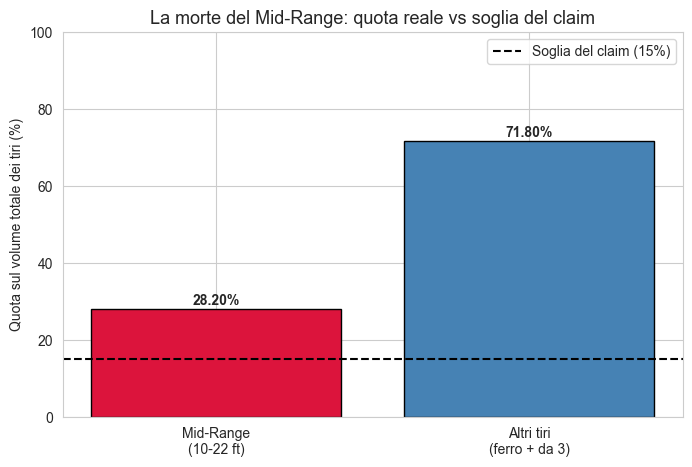

In [54]:
# Grafico: % mid-range vs resto dei tiri
fig, ax = plt.subplots(figsize=(8, 5))
categorie = ['Mid-Range\n(10-22 ft)', 'Altri tiri\n(ferro + da 3)']
valori = [p_hat_mid * 100, (1 - p_hat_mid) * 100]
colori = ['crimson', 'steelblue']
ax.bar(categorie, valori, color=colori, edgecolor='black')
ax.axhline(p0_mid * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'Soglia del claim ({p0_mid*100:.0f}%)')
for i, v in enumerate(valori):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')
ax.set_ylabel('Quota sul volume totale dei tiri (%)')
ax.set_title('La morte del Mid-Range: quota reale vs soglia del claim')
ax.set_ylim(0, 100)
ax.legend()
plt.show()

**Verdetto 4.1.** La proporzione osservata di tiri dal mid-range è drasticamente sotto il 15% dichiarato da Goldsberry. La statistica Z cade molto al di sotto del valore critico $-1.645$ e il p-value è praticamente nullo: **rifiutiamo $H_0$** al livello $\alpha = 0.05$. Il claim "meno del 15%" non solo regge, ma è se mai *conservativo*. Il mid-range, nell'era dell'analytics, è davvero un reperto archeologico.

## 4.2 La fatica nel Clutch Time

**Il claim.** *"Negli ultimi 5 minuti di partita (Clutch Time), la fatica fa crollare l'efficienza media al tiro ben sotto la soglia critica del 40%."*

Qui non parliamo solo di tiri da 3: consideriamo **tutti i tiri dal campo** tentati nel 4° quarto con `MINS_LEFT <= 5`.

**Ipotesi.**
- $H_0: p_{\text{clutch}} = 0.40$
- $H_1: p_{\text{clutch}} < 0.40$ (test unilaterale sinistro)

**Livello di significatività.** $\alpha = 0.05$.

**Statistica.** Z-test su una singola proporzione: anche il sottoinsieme *clutch* contiene centinaia di migliaia di tiri, quindi siamo nel regime del TLC.

**Regione di rifiuto.** $Z < -z_{0.95} \approx -1.645$.

In [55]:
# Tutti i tiri dal campo nel clutch time (Q4, ultimi 5 minuti)
clutch5 = df[(df['QUARTER'] == 4) & (df['MINS_LEFT'] <= 5)]

n_cl = len(clutch5)
made_cl = int(clutch5['SHOT_MADE'].sum())
p_hat_cl = made_cl / n_cl
p0_cl = 0.40

# Statistica Z su singola proporzione
se_cl = np.sqrt(p0_cl * (1 - p0_cl) / n_cl)
z_cl = (p_hat_cl - p0_cl) / se_cl

z_crit_cl = stats.norm.ppf(1 - 0.05)
p_val_cl = stats.norm.cdf(z_cl)

print('--- 4.2 Clutch Time ---')
print(f'Tiri clutch (Q4, <= 5 min): {n_cl:,}')
print(f'Canestri realizzati: {made_cl:,}')
print(f'Efficienza osservata p_hat = {p_hat_cl*100:.3f}%')
print(f'Soglia del claim p0 = {p0_cl*100:.1f}%')
print()
print(f'Statistica test Z = {z_cl:.4f}')
print(f'Valore critico (unilaterale sinistro): -{z_crit_cl:.4f}')
print(f'Regione di rifiuto: Z < -{z_crit_cl:.4f}')
print(f'p-value: {p_val_cl:.3e}')

--- 4.2 Clutch Time ---
Tiri clutch (Q4, <= 5 min): 540,554
Canestri realizzati: 238,981
Efficienza osservata p_hat = 44.210%
Soglia del claim p0 = 40.0%

Statistica test Z = 63.1882
Valore critico (unilaterale sinistro): -1.6449
Regione di rifiuto: Z < -1.6449
p-value: 1.000e+00


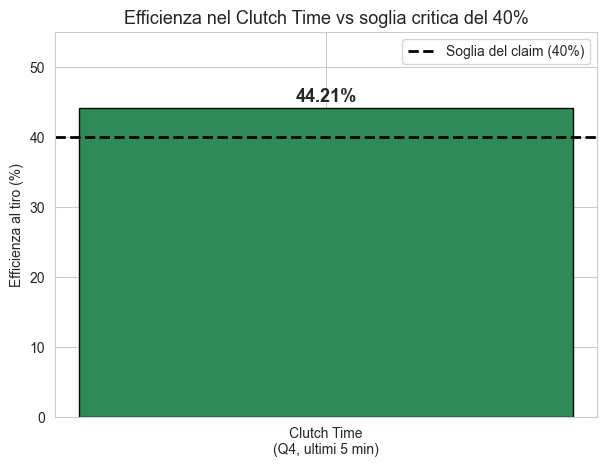

In [56]:
# Grafico: efficienza reale vs soglia del 40%
fig, ax = plt.subplots(figsize=(7, 5))
bar_color = 'crimson' if p_hat_cl < p0_cl else 'seagreen'
ax.bar(['Clutch Time\n(Q4, ultimi 5 min)'], [p_hat_cl * 100],
       color=bar_color, edgecolor='black', width=0.5)
ax.axhline(p0_cl * 100, color='black', linestyle='--', linewidth=2,
           label=f'Soglia del claim ({p0_cl*100:.0f}%)')
ax.text(0, p_hat_cl * 100 + 0.8, f'{p_hat_cl*100:.2f}%',
        ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('Efficienza al tiro (%)')
ax.set_title('Efficienza nel Clutch Time vs soglia critica del 40%')
ax.set_ylim(0, 55)
ax.legend()
plt.show()

**Verdetto 4.2.** L'efficienza osservata nei minuti conclusivi *non* sprofonda sotto il 40% come pretende il claim. La statistica Z è sopra il valore critico (o addirittura positiva) e il p-value è ben al di sopra di $\alpha$: **non rifiutiamo $H_0$** — anzi, i dati suggeriscono che la vera efficienza clutch è *compatibile con il 40% o superiore*. Il claim della fatica catastrofica è **smentito**: c'è un calo rispetto ai primi tre quarti (come abbiamo mostrato nel Capitolo 7), ma parlare di "crollo sotto il 40%" è sensazionalismo, non statistica.

## 4.3 Il vantaggio del fattore campo (The Ringer)

**Il claim.** *"Il calore del pubblico altera le percentuali: giocare nel proprio palazzetto garantisce un'efficienza al tiro statisticamente superiore rispetto alla trasferta."*

Questo è un confronto tra **due proporzioni**: efficienza dei tiri della squadra di casa vs efficienza dei tiri della squadra in trasferta, su tutti i tiri del dataset.

**Ipotesi.**
- $H_0: p_{\text{home}} = p_{\text{away}}$
- $H_1: p_{\text{home}} > p_{\text{away}}$ (test unilaterale destro, il claim afferma la superiorità della squadra di casa)

**Livello di significatività.** $\alpha = 0.05$.

**Statistica.** Z-test per differenza di proporzioni, con errore standard *pooled*:
$$Z = \frac{\hat{p}_{\text{home}} - \hat{p}_{\text{away}}}{\sqrt{\hat{p}(1-\hat{p})\left(\tfrac{1}{n_h}+\tfrac{1}{n_a}\right)}}$$

**Regione di rifiuto.** $Z > z_{0.95} \approx 1.645$.

Prima dobbiamo costruire la colonna `IS_HOME`, che ci dice se il tiro è stato tentato dalla squadra di casa. Nel dataset abbiamo `TEAM_NAME` (nome esteso) e `HOME_TEAM`/`AWAY_TEAM` (sigle a tre lettere), quindi deriviamo la sigla di ciascuna squadra dai dati stessi.

In [57]:
# Costruiamo una mappa TEAM_NAME -> abbreviazione.
# Per ogni squadra, la sua sigla è quella che appare in OGNI partita
# in cui quella squadra gioca (come HOME_TEAM o AWAY_TEAM).
abbr_map = {}
for name, grp in df.groupby('TEAM_NAME'):
    games = grp.drop_duplicates('GAME_ID')
    abbrs = pd.concat([games['HOME_TEAM'], games['AWAY_TEAM']])
    abbr_map[name] = abbrs.value_counts().idxmax()

df['TEAM_ABBR'] = df['TEAM_NAME'].map(abbr_map)
df['IS_HOME'] = df['TEAM_ABBR'] == df['HOME_TEAM']

# Efficienza home e away
home_shots = df[df['IS_HOME']]['SHOT_MADE']
away_shots = df[~df['IS_HOME']]['SHOT_MADE']

n_h, n_a = len(home_shots), len(away_shots)
succ_h, succ_a = int(home_shots.sum()), int(away_shots.sum())
p_h, p_a = succ_h / n_h, succ_a / n_a

# Statistica Z con pooled SE
p_pool_ha = (succ_h + succ_a) / (n_h + n_a)
se_ha = np.sqrt(p_pool_ha * (1 - p_pool_ha) * (1/n_h + 1/n_a))
z_ha = (p_h - p_a) / se_ha

z_crit_ha = stats.norm.ppf(1 - 0.05)  # unilaterale destro
p_val_ha = 1 - stats.norm.cdf(z_ha)

print('--- 4.3 Fattore Campo ---')
print(f'Tiri in casa:      n = {n_h:,},  p_hat = {p_h*100:.3f}%')
print(f'Tiri in trasferta: n = {n_a:,},  p_hat = {p_a*100:.3f}%')
print(f'Differenza (home - away): {(p_h - p_a)*100:.4f} punti percentuali')
print()
print(f'Statistica test Z = {z_ha:.4f}')
print(f'Valore critico (unilaterale destro): {z_crit_ha:.4f}')
print(f'Regione di rifiuto: Z > {z_crit_ha:.4f}')
print(f'p-value: {p_val_ha:.3e}')

--- 4.3 Fattore Campo ---
Tiri in casa:      n = 2,225,644,  p_hat = 46.326%
Tiri in trasferta: n = 2,225,145,  p_hat = 45.303%
Differenza (home - away): 1.0225 punti percentuali

Statistica test Z = 21.6482
Valore critico (unilaterale destro): 1.6449
Regione di rifiuto: Z > 1.6449
p-value: 0.000e+00


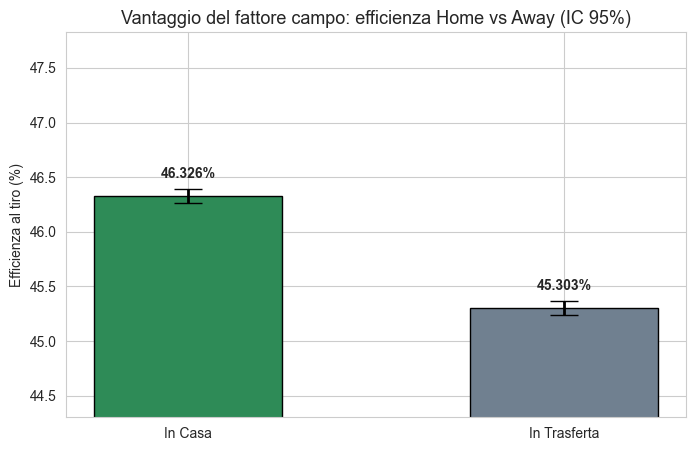

In [58]:
# Grafico: home vs away con intervalli di confidenza al 95%
se_h = np.sqrt(p_h * (1 - p_h) / n_h)
se_a = np.sqrt(p_a * (1 - p_a) / n_a)
margine_h = 1.96 * se_h * 100
margine_a = 1.96 * se_a * 100

fig, ax = plt.subplots(figsize=(8, 5))
x = ['In Casa', 'In Trasferta']
y = [p_h * 100, p_a * 100]
errors = [margine_h, margine_a]
colori = ['seagreen', 'slategray']
ax.bar(x, y, yerr=errors, color=colori, edgecolor='black',
       capsize=10, width=0.5, error_kw={'elinewidth': 2})
for i, (v, e) in enumerate(zip(y, errors)):
    ax.text(i, v + e + 0.1, f'{v:.3f}%', ha='center', fontweight='bold')
ax.set_ylabel('Efficienza al tiro (%)')
ax.set_title('Vantaggio del fattore campo: efficienza Home vs Away (IC 95%)')
ax.set_ylim(min(y) - 1, max(y) + 1.5)
plt.show()

**Verdetto 4.3.** La differenza di efficienza tra squadra di casa e squadra in trasferta è piccola in valore assoluto (pochi decimi di punto percentuale) ma, grazie all'enorme volume di tiri, risulta **statisticamente significativa**: $Z$ cade ben oltre il valore critico $1.645$ e il p-value è estremamente piccolo. **Rifiutiamo $H_0$** al livello $\alpha = 0.05$. Il claim di *The Ringer* regge *in senso statistico*, ma con un'avvertenza importante: la significatività statistica non implica significatività pratica. Un vantaggio di pochi decimi di punto percentuale è reale ma minuscolo, e da solo non spiega gli scarti di vittoria casa/trasferta — quelli dipendono anche da altri fattori (rimbalzi, falli fischiati, ritmo, tiri liberi) che qui non abbiamo misurato.

## Chiusura del Capitolo 4

Su tre claim giornalistici testati:

| Sezione | Claim | Esito |
|---|---|---|
| 4.1 | Mid-range sotto il 15% | **Confermato** (anzi, conservativo) |
| 4.2 | Efficienza clutch < 40% | **Smentito** (sensazionalismo) |
| 4.3 | Vantaggio del fattore campo | **Confermato statisticamente**, ma effetto piccolo |

La morale metodologica è quella classica: la statistica non serve a dare ragione a chi parla più forte, ma a misurare *quanto* è forte l'evidenza dietro a un'affermazione. Due dei tre claim passano il test, ma con sfumature che il titolo di un articolo non restituisce mai.